# Utils
- Implementation of the Tabata upwind scheme and AFC methods with Kuzmin and BJK limiters
- Functions to save the computed data in a format readable by torch

In [254]:
import ufl
from dolfinx import default_scalar_type, fem, la, mesh as msh, plot, io
from dolfinx.fem import functionspace
import numpy as np
import scipy
from FEniCSx_solver import plot_fn
from mpi4py import MPI
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells, BoundingBoxTree

# Creates a dolfinx.fem.Function from a ufl.form, fem.expression or fem.funciton

def interpolate_expr(expr, Wh):
    f = fem.Function(Wh)
    if expr ==None:
        fem_expr = fem.Expression(fem.Constant(Wh.mesh, default_scalar_type(0)), Wh.element.interpolation_points())
    else:
        fem_expr = fem.Expression(expr, Wh.element.interpolation_points())
    f.interpolate(fem_expr)
    return f

# creates a system matrix from a bilinear ufl.form
def expr_to_mat(
        expr:ufl.Form
):
    
    expr_compiled = fem.form(expr)
    mat = fem.create_matrix(expr_compiled)
    A = mat.to_scipy()

    fem.assemble_matrix(mat, expr_compiled)
    return A

# Sets Dirichlet boundary values for specified dofs by zeroing rowsat each dof and setting the diagonal values to 1 and the lhs vector to uD at each dof
def set_dbc_vals(
        dbc_dofs:np.ndarray, 
        uD:np.ndarray,
        A:scipy.sparse.csr_matrix, 
        L:np.ndarray
    ):
    for dof in dbc_dofs:
        indices = A[dof].indices
        A[dof,indices] = 0.0
        A[dof, dof] = 1.0
        L[dof] = uD.x.array[dof]

# Computes the upwind element for a node in a triangular mesh
def compute_upwind_element(
        mesh:msh.Mesh,
        node:int,
        b1:fem.Function,
        b2:fem.Function,
        factor:float=1e-12
    ):
    tdim = mesh.topology.dim

    mesh.topology.create_connectivity(0, tdim)
    mesh.topology.create_connectivity(tdim, 0)

    adjacent_cells = msh.compute_incident_entities(
        mesh.topology,
        np.array([node], dtype=np.int32),
        0,
        tdim,
    )

    x = mesh.geometry.x
    xv = x[node]

    b = np.array([
        -b1.x.array[node],
        -b2.x.array[node],
    ])

    c_to_v = mesh.topology.connectivity(tdim, 0)

    for cell in adjacent_cells:
        verts = c_to_v.links(cell)

        others = verts[verts != node]
        e1 = x[others[0], :2] - xv[:2]
        e2 = x[others[1], :2] - xv[:2]

        # orient cone counterclockwise
        if np.cross(e1, e2) < 0:
            e1, e2 = e2, e1

        if np.cross(e1, b) >= -factor and np.cross(b, e2) >= -factor:
            return cell

    return None

# Computes which indices of a DG1 space corresponds to which index in the corresponding P1 space
def compute_idx_n(Wh, DWh):
    b = DWh.tabulate_dof_coordinates()
    a = Wh.tabulate_dof_coordinates()
    decimals = 12

    lookup = {
        tuple(np.round(row, decimals)): i
        for i, row in enumerate(a)
    }

    idx_n = np.array([
        lookup[tuple(np.round(row, decimals))]
        for row in b
    ])
    return idx_n

# computes which cell corresponds to which DG0 dof
def compute_idx_c(
        mesh:msh.Mesh,
        DWh:fem.FunctionSpace
):
    num_cells = mesh.topology.index_map(2).size_global
    num_dofs = len(DWh.dofmap.list.reshape(-1))
    idx_c = np.zeros(num_dofs)
    for c in range(num_cells):
        dofs = fem.locate_dofs_topological(DWh, 2, np.array([c]))
        if np.all(idx_c[dofs] == 0):
            idx_c[dofs] = c
    return idx_c

# computes a CG dof from a DG0 index and a cell index
def node_K_to_CG_dof(
        node:int, 
        K:int, 
        idx_n:np.ndarray, 
        idx_c:np.ndarray
    ):
    arr_j = np.where(idx_n==node)
    arr_K = np.where(idx_c==K)
    dofs = np.intersect1d(arr_j, arr_K)
    if len(dofs) > 0:
        return dofs[0]

# computes the system matrix for the Tabata method
def upwinding_mat(
        mesh:msh.Mesh,
        b:ufl.Form,
        Wh:fem.FunctionSpace,
        u:ufl.Argument,
        v:ufl.Argument
):
    mesh.topology.create_connectivity(0,2)
    mesh.topology.create_connectivity(2,2)
    tree = bb_tree(mesh, mesh.topology.dim)

    DWh = fem.functionspace(mesh=mesh, element=('DG', 1))
    ud = ufl.TrialFunction(DWh)
    vd = ufl.TestFunction(DWh)

    idx_n = compute_idx_n(Wh=Wh, DWh=DWh)
    idx_c = compute_idx_c(mesh=mesh, DWh=DWh)

    b1 = interpolate_expr(b[0], Wh)
    b2 = interpolate_expr(b[1], Wh)


    num_nodes = mesh.topology.index_map(0).size_global

    a = (u.dx(0) + u.dx(1)) * v * ufl.dx

    A = expr_to_mat(a)

    d1 = ud.dx(0) * vd * ufl.dx
    D1 = expr_to_mat(d1)


    d2 = ud.dx(1) * vd * ufl.dx
    D2 = expr_to_mat(d2)

    for i in range(num_nodes):
        indices = A[i].indices
        A[i,indices] = 0
        K = compute_upwind_element(mesh=mesh, node=i, b1=b1, b2=b2)
        if K != None:
            row = node_K_to_CG_dof(node=i, K=K, idx_n=idx_n, idx_c=idx_c)
            for c in indices:
                col = node_K_to_CG_dof(node=c, K=K, idx_n=idx_n, idx_c=idx_c)
                if col:
                    A[i, c] = b1.x.array[i]*D1[row, col] + b2.x.array[i]*D2[row,col]

    return A

# Computes Tabat solution
def tabata(
        mesh:msh.Mesh,
        uD:fem.Function,
        dbc_dofs:np.ndarray,
        eps:fem.Constant, 
        b:ufl.Form|fem.Constant, 
        f:ufl.Form|fem.Constant,
        c:ufl.Form|fem.Constant=None,
        ):
    Wh = fem.functionspace(mesh=mesh, element=('CG', 1))
    u = ufl.TrialFunction(function_space=Wh)
    v = ufl.TestFunction(function_space=Wh)


    diff_form = eps * u * v * ufl.dx
    D = expr_to_mat(diff_form)
    C = upwinding_mat(mesh=mesh, b=b, Wh=Wh, u=u, v=v)
    A = D + C
    if c:
        reaction_form = c * u * v * ufl.dx
        R = expr_to_mat(reaction_form)
        A += R
    farr = interpolate_expr(expr=f, Wh=Wh).x.array
    L = farr * fem.assemble_vector(fem.form(v*ufl.dx)).array
    for dof in dbc_dofs:
        indices = A[dof].indices
        A[dof,indices] = 0.0
        A[dof, dof] = 1.0
        L[dof] = uD[dof]

    res = scipy.sparse.linalg.spsolve(A, L)
    return res

# computes directional diamater from a vector field b
def directional_diameter(mesh, b):


    tdim = mesh.topology.dim
    assert tdim == 2, "Only 2D triangles supported."

    mesh.topology.create_connectivity(tdim, 0)
    c_to_v = mesh.topology.connectivity(tdim, 0)

    Vdg = fem.functionspace(mesh, ("DG", 0, (2,)))
    b0 = fem.Function(Vdg)

    expr = fem.Expression(
        b,
        Vdg.element.interpolation_points()
    )
    b0.interpolate(expr)

    b_arr = b0.x.array.reshape((-1, 2))

    V0 = fem.functionspace(mesh, ("DG", 0))
    out = fem.Function(V0)

    imap = mesh.topology.index_map(tdim)
    ncells = imap.size_local + imap.num_ghosts
    cells = np.arange(ncells, dtype=np.int32)

    # barycenters
    bary = msh.compute_midpoints(mesh, tdim, cells)

    values = np.zeros(ncells, dtype=np.float64)

    for cell in cells:

        p = bary[cell][:2]
        d = b_arr[cell]

        norm_d = np.linalg.norm(d)
        if norm_d < 1e-14:
            values[cell] = 0.0
            continue

        d = d / norm_d

        verts = mesh.geometry.x[c_to_v.links(cell)][:, :2]

        tvals = []

        for k in range(3):

            a = verts[k]
            b_edge = verts[(k + 1) % 3]
            edge = b_edge - a

            A = np.column_stack((d, -edge))
            rhs = a - p

            det = np.linalg.det(A)
            if abs(det) < 1e-14:
                continue

            t, s = np.linalg.solve(A, rhs)

            if -1e-12 <= s <= 1 + 1e-12:
                tvals.append(t)

        if len(tvals) >= 2:
            tvals = np.array(tvals)
            values[cell] = np.max(tvals) - np.min(tvals)
        else:
            values[cell] = 0.0

    out.x.array[:] = values
    return out

# AFC Kuzmin solver
class F_AFC_Kuzmin:
    def __init__(
            self, 
            A:scipy.sparse.csr_matrix,
            f:np.ndarray,
            dbc_dofs:np.ndarray
        ) -> None:
        self.A = A
        self.f = f
        self.dbc_dofs = dbc_dofs
        cx = A.tocoo()
        self.col = cx.col
        self.row = cx.row

        self.D, self.U = self.build_D_U(A=A)
        self.B = A.copy()

        self.Fplus = A.copy()
        self.Fminus = A.copy()
        self.upwind_Fplus = A.copy()
        self.upwind_Fminus = A.copy()
        self.TildeAlpha = A.copy()
        self.Alpha = A.copy()

        self.F = A.copy()



    def __call__(
            self,
            u:np.ndarray
        ) -> np.ndarray:
        
        u_j = u[self.col]
        u_i = u[self.row]

        self.F.data = self.D.data*(u_j-u_i)


        self.Fplus.data = np.maximum(self.F.data,0)
        self.Fminus.data = np.minimum(self.F.data,0)

        self.upwind_Fplus.data = self.U.data * self.Fplus.data
        self.upwind_Fminus.data = self.U.data * self.Fminus.data

        Pplus = np.array(self.upwind_Fplus.sum(axis=1)).flatten()
        Pminus = np.array(self.upwind_Fminus.sum(axis=1)).flatten()

        Qplus = -np.array(self.Fminus.sum(axis=1)).flatten()
        Qminus = -np.array(self.Fplus.sum(axis=1)).flatten()


        Rplus = np.minimum(np.divide(Qplus, Pplus, out=np.ones_like(Qplus), where=(Pplus!=0)), 1)
        Rminus = np.minimum(np.divide(Qminus, Pminus, out=np.ones_like(Qminus), where=(Pminus!=0)), 1)
        Rplus[self.dbc_dofs] = 1
        Rminus[self.dbc_dofs] = 1
        self.TildeAlpha.data[:] = 1
        self.TildeAlpha.data[self.F.data>0] = Rplus[self.row][self.F.data>0]
        self.TildeAlpha.data[self.F.data<0] = Rminus[self.row][self.F.data<0]

        self.Alpha.data = self.U.data*self.TildeAlpha.data #+ self.U.data*self.TildeAlpha.T.data
        


        self.B.data[:] = (1-self.Alpha.data)*self.D.data
        self.B.setdiag(0)
        self.B.setdiag(-self.B.sum(axis=1))
        return (self.A+self.B) * u -self.f

    def build_D_U(
            self,
            A: scipy.sparse.csr_matrix
        ) -> scipy.sparse.csr_matrix:


        pairs = {(min(i, j), max(i, j))
                for i, j in zip(self.row, self.col) if i != j}
        D = A.copy()
        D.data[:] = 0

        U = A.copy()
        U.data[:] = 0


        for (i, j) in pairs:
            a_ij = A[i, j]
            a_ji = A[j, i]
            d = -float(max(0.0, a_ij, a_ji))
            if d < 0:
                D[i, j] += d
                D[j, i] += d

            if a_ij >= a_ji:
                U[i,j] = 1
                U[j,i] = 0
            else:
                U[i,j] = 0
                U[j,i] = 1
        D.setdiag(0)
        D.setdiag(-D.sum(axis=1))

        return D.tocsr(), U.tocsr()
    
    def optimize(
            self,
            u0:np.ndarray,
            ftol:float=1e-12,
            maxiter:int=1000,
            method:str = 'krylov'
    ):
        monitor = ConvergenceMonitor(self.__call__)
        result = scipy.optimize.root(
            self.__call__, 
            u0, 
            method=method, 
            callback=monitor, 
            options={'maxiter': maxiter, 'fatol': ftol}
        )
        print(result)
        return result.x, monitor
    
# AFC BJK solver
class F_AFC_BJK:
    def __init__(
            self, 
            A:scipy.sparse.csr_matrix,
            f:np.ndarray,
            dbc_dofs:np.ndarray,
            gamma:np.ndarray|float = 1.0
        ) -> None:
        assert np.min(np.diff(A.indptr)) > 0, "System matrix shouldn't have empty rows."
        cx = A.tocoo()
        self.col = cx.col
        self.row = cx.row
        
        self.A = A.copy()
        self.f = f
        self.gamma = gamma
        self.dbc_dofs = dbc_dofs

        self.D = self.build_D(A=A)
        self.B = A.copy()

        self.Fplus = A.copy()
        self.Fminus = A.copy()
        self.upwind_Fplus = A.copy()
        self.upwind_Fminus = A.copy()
        self.TildeAlpha = A.copy()
        self.Alpha = A.copy()

        self.F = A.copy()



    def __call__(
            self,
            u:np.ndarray
        ) -> np.ndarray:
        u_j = u[self.col]
        u_i = u[self.row]

        u_max = np.maximum.reduceat(u_j, self.A.indptr[:-1]) 
        u_min = np.minimum.reduceat(u_j, self.A.indptr[:-1]) 
        self.F.data = self.D.data*(u_j-u_i)


        self.Fplus.data = np.maximum(self.F.data,0)
        self.Fminus.data = np.minimum(self.F.data,0)


        Pplus = np.array(self.Fplus.sum(axis=1)).flatten()
        Pminus = np.array(self.Fminus.sum(axis=1)).flatten()
        
        Qplus = -self.gamma*self.D.diagonal()*(u - u_max)
        Qminus = -self.gamma*self.D.diagonal()*(u-u_min)


        Rplus = np.minimum(np.divide(Qplus, Pplus, out=np.ones_like(Qplus), where=(Pplus!=0)), 1)
        Rminus = np.minimum(np.divide(Qminus, Pminus, out=np.ones_like(Qminus), where=(Pminus!=0)), 1)
        Rplus[self.dbc_dofs] = 1
        Rminus[self.dbc_dofs] = 1
        self.TildeAlpha.data[:] = 1
        self.TildeAlpha.data[self.F.data>0] = Rplus[self.row][self.F.data>0]
        self.TildeAlpha.data[self.F.data<0] = Rminus[self.row][self.F.data<0]

        self.Alpha.data = np.minimum(self.TildeAlpha.data, self.TildeAlpha.T[self.row, self.col].A1) 
        


        self.B.data[:] = (1-self.Alpha.data)*self.D.data
        self.B.setdiag(0)
        self.B.setdiag(-self.B.sum(axis=1))
        return (self.A+self.B) * u -self.f

    def build_D(
            self,
            A: scipy.sparse.csr_matrix
        ) -> scipy.sparse.csr_matrix:
        
        pairs = {(min(i, j), max(i, j))
                for i, j in zip(self.row, self.col) if i != j}
        D = A.copy()
        D.data[:] = 0


        for (i, j) in pairs:
            a_ij = A[i, j]
            a_ji = A[j, i]
            d = -float(max(0.0, a_ij, a_ji))
            if d < 0:
                D[i, j] += d
                D[j, i] += d

        D.setdiag(0)
        D.setdiag(-D.sum(axis=1))

        return D.tocsr()
    
    def optimize(
            self,
            u0:np.ndarray,
            ftol:float=1e-12,
            maxiter:int=1000,
            method:str = 'krylov'
    ):
        monitor = ConvergenceMonitor(self.__call__)
        result = scipy.optimize.root(
            self.__call__, 
            u0, 
            method=method, 
            callback=monitor, 
            options={'maxiter': maxiter, 'fatol': ftol}
        )
        print(result)
        return result.x, monitor
    
class ConvergenceMonitor:
    def __init__(self, F):
        self.F = F
        self.iteration = 0
        self.residuals = []

    def __call__(self, u, *args):
        res = np.linalg.norm(self.F(u))
        self.residuals.append(res)
        print(f"Iter {self.iteration:4d} | ||F(u)|| = {res:.6e}")
        self.iteration += 1

import torch
from torch_geometric.data import Data

# computes standard SUPG parameter
def yh_std(h, eps=1e-8, norm_b=1):
    Pe = h*norm_b/(2*eps)
    tau_K = h*(1/np.tanh(Pe)-1/Pe)/(2*norm_b)
    return tau_K

# # computes edge indices
def fs_to_edge_index(fs):
    fs.domain.topology.create_connectivity(2,0)
    conn = fs.domain.topology.connectivity(2,0)
    source_index = []
    target_index = []
    num_cells = len(fs.yh.x.array)
    for cur_cell in range(num_cells):
        for cell in range(num_cells):
            if np.intersect1d(conn.links(cur_cell), conn.links(cell)) .size>0:
                source_index.append(cur_cell)
                target_index.append(cell)

    edge_index = torch.tensor([source_index, target_index], dtype=torch.long)
    return edge_index

# computes different x values for networks
def fs_to_x(fs, u_tabata):
    h = interpolate_expr(ufl.CellDiameter(fs.uh.function_space.mesh), fs.Yh).x.array
    hb = directional_diameter(fs.domain, fs.b).x.array
    hbp = directional_diameter(fs.domain, ufl.perp(fs.b)).x.array
    fs.set_weights(yh_std(h=h))
    u_std = interpolate_expr(fs.uh, fs.Yh).x.array
    u_std_x = interpolate_expr(fs.uh.dx(0), fs.Yh).x.array
    u_std_y = interpolate_expr(fs.uh.dx(1), fs.Yh).x.array

    fs.set_weights(yh_std(h=hb))
    u_std_b = np.max(interpolate_expr(fs.uh, fs.Wh).x.array[fs.Wh.dofmap.list], axis=1)
    u_std_x_b = np.max(interpolate_expr(fs.uh.dx(0), fs.Wh).x.array[fs.Wh.dofmap.list], axis=1)
    u_std_y_b = np.max(interpolate_expr(fs.uh.dx(1), fs.Wh).x.array[fs.Wh.dofmap.list], axis=1)

    b0 = fs.b[0].value*np.ones_like(u_std)
    b1 = fs.b[1].value*np.ones_like(u_std)
    eps = fs.eps.value*np.ones_like(u_std)
    f = np.zeros_like(u_std)
    c = np.zeros_like(u_std)

    x0 = torch.tensor(
        [
            eps,
            b0,
            b1,
            c,
            f,
            h,
            u_std,
            u_std_x,
            u_std_y
        ],dtype=torch.float32
    )
    utab = np.mean(u_tabata.copy()[fs.Wh.dofmap.list], axis=1)
    x1 = torch.tensor(
        [
            eps,
            b0,
            b1,
            c,
            f,
            hb,
            hbp,
            u_std_b,
            u_std_x_b,
            u_std_y_b,
            utab
        ],dtype=torch.float32
    )

    nabla_u_std_b = np.sqrt(u_std_x_b**2 + u_std_y_b**2)
    u_diff = np.max(np.abs(interpolate_expr(fs.uh, fs.Wh).x.array-u_tabata)[fs.Wh.dofmap.list], axis=1)
    x2 = torch.tensor(
        [
            hb/eps,
            hbp/hb,
            hb*nabla_u_std_b,
            u_diff
        ],dtype=torch.float32
    )
    return x0.T, x1.T, x2.T


# save values for training
def save_input_data(num, fs, y_optimized, u_optimized, y_optimized_b, y_optimized_z, y_optimized_l, u_optimized_b, u_optimized_z, u_optimized_l, u_kuzmin, u_bjk, u_tabata):
    x0, x1, x2=fs_to_x(fs, u_tabata=u_tabata)
    fs.set_weights(yh_std(h=interpolate_expr(ufl.CellDiameter(fs.uh.function_space.mesh), fs.Yh).x.array))
    u_std = fs.uh.x.array.copy()
    fs.set_weights(yh_std(directional_diameter(fs.domain, fs.b).x.array))
    u_std_b = fs.uh.x.array.copy()
    midpoints = torch.tensor(fs.Yh.tabulate_dof_coordinates()[:,0:2], dtype=torch.float32)
    nodes = torch.tensor(fs.domain.geometry.x[fs.Wh.dofmap.list][:,0:2], dtype=torch.float32)
    ls=[]

    for bcs in fs.bcs:
        ls.append(bcs.dof_indices()[0])
    dbc_dofs=torch.tensor(ls, dtype=torch.int32)


    fs.domain.topology.create_connectivity(1, 2)
    boundary_facets = msh.exterior_facet_indices(fs.domain.topology)
    boundary_dofs = fem.locate_dofs_topological(fs.Wh, 1, boundary_facets)
    n = ufl.FacetNormal(fs.domain)
    v = ufl.TestFunction(fs.Wh)
    frm = ufl.dot(fs.b,n) * v * ufl.ds
    vec = fem.assemble_vector(fem.form(frm)).array  
    inflow_dofs = torch.tensor(np.where(vec<0)[0], dtype=torch.int32)
    outflow_dofs = torch.tensor(np.where(vec>0)[0], dtype=torch.int32)
    interior_dofs = np.setdiff1d(np.arange(len(fs.yh.x.array)), boundary_dofs)
    G = Data(
        edge_index=fs_to_edge_index(fs), 
        x0=torch.tensor(data=x0, dtype=torch.float32), 
        x1=torch.tensor(data=x1, dtype=torch.float32), 
        x2=torch.tensor(data=x2, dtype=torch.float32), 
        yh_std=torch.tensor(data=yh_std(h=interpolate_expr(ufl.CellDiameter(fs.uh.function_space.mesh), fs.Yh).x.array), dtype=torch.float32).reshape(-1,1),
        yh_std_b=torch.tensor(data=yh_std(directional_diameter(fs.domain, fs.b).x.array), dtype=torch.float32).reshape(-1,1),
        y_optimized=torch.tensor(data=y_optimized, dtype=torch.float32).reshape(-1,1),
        y_optimized_b=torch.tensor(data=y_optimized_b, dtype=torch.float32).reshape(-1,1),
        y_optimized_z=torch.tensor(data=y_optimized_z, dtype=torch.float32).reshape(-1,1),
        y_optimized_l=torch.tensor(data=y_optimized_l, dtype=torch.float32).reshape(-1,1),
        u_std=torch.tensor(data=u_std, dtype=torch.float32),
        u_std_b=torch.tensor(data=u_std_b, dtype=torch.float32),
        u_optimized=torch.tensor(data=u_optimized, dtype=torch.float32),
        u_optimized_b=torch.tensor(data=u_optimized_b, dtype=torch.float32),
        u_optimized_z=torch.tensor(data=u_optimized_z, dtype=torch.float32),
        u_optimized_l=torch.tensor(data=u_optimized_l, dtype=torch.float32),
        u_kuzmin=torch.tensor(data=u_kuzmin, dtype=torch.float32),
        u_bjk=torch.tensor(data=u_bjk, dtype=torch.float32),
        midpoints=midpoints,
        nodes=nodes,
        points=torch.tensor(fs.domain.geometry.x[:, :2].copy(), dtype=torch.float32),
        boundary_dofs=torch.tensor(boundary_dofs, dtype=torch.int32),
        dbc_dofs=dbc_dofs,
        inflow_dofs=inflow_dofs,
        outflow_dofs=outflow_dofs,
        interior_dofs=torch.tensor(interior_dofs, dtype=torch.int32)
    )
    torch.save(G, f"data/revised_set/input_values/raw/G_{num}.pt")

    with io.XDMFFile(fs.domain.comm, f"data/revised_set/mesh_files/mesh_{num}.xdmf", "w") as writer:
        writer.write_mesh(fs.domain)


# Unstructured mesh of Delaunay type

In [68]:
from mpi4py import MPI
import gmsh
import basix

from dolfinx.io import gmshio

# --------------------------------------------------
# Initialize gmsh
# --------------------------------------------------
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)

model = gmsh.model
model.add("delaunay_square")

# --------------------------------------------------
# Geometry
# --------------------------------------------------
lc = 0.05

p1 = model.geo.addPoint(0.0, 0.0, 0.0, lc)
p2 = model.geo.addPoint(1.0, 0.0, 0.0, lc)
p3 = model.geo.addPoint(1.0, 1.0, 0.0, lc)
p4 = model.geo.addPoint(0.0, 1.0, 0.0, lc)

l1 = model.geo.addLine(p1, p2)
l2 = model.geo.addLine(p2, p3)
l3 = model.geo.addLine(p3, p4)
l4 = model.geo.addLine(p4, p1)

cl = model.geo.addCurveLoop([l1, l2, l3, l4])
surface = model.geo.addPlaneSurface([cl])

model.geo.synchronize()

# Physical tags (required for robust import)
model.addPhysicalGroup(2, [surface], 1)
model.addPhysicalGroup(1, [l1], 11)
model.addPhysicalGroup(1, [l2], 12)
model.addPhysicalGroup(1, [l3], 13)
model.addPhysicalGroup(1, [l4], 14)

# --------------------------------------------------
# Delaunay triangular mesh
# --------------------------------------------------
gmsh.option.setNumber("Mesh.Algorithm", 5)
# 5 = Delaunay

model.mesh.generate(2)

# --------------------------------------------------
# Convert to DOLFINx mesh
# --------------------------------------------------
mesh_data = gmshio.model_to_mesh(
    model,
    MPI.COMM_WORLD,
    rank=0,
)

mesh = mesh_data[0]

gmsh.finalize()

print(
    f"Cells = {mesh.topology.index_map(mesh.topology.dim).size_local}"
)

points = mesh.geometry.x[:, :2].copy()

# Extract triangle connectivity
tdim = mesh.topology.dim
mesh.topology.create_connectivity(tdim, 0)

cells = mesh.topology.connectivity(tdim, 0).array.reshape(-1, 3)
# ----------------------------------
# Create a true 2D mesh
# ----------------------------------
domain = c_el = ufl.Mesh(basix.ufl.element("Lagrange", "triangle", 1, shape=(points.shape[1],)))

mesh = msh.create_mesh(
    MPI.COMM_WORLD,
    cells,
    points,
    domain,
)

print("tdim =", mesh.topology.dim)
print("gdim =", mesh.geometry.dim)


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000570041s, CPU 0.000687s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 0.00793571s, CPU 0.009398s)
Info    : 568 nodes 1138 elements
Cells = 1054
tdim = 2
gdim = 2


# Problem definition and approximations
- Mesh is uniform triangular, created from $32\times 32$ squares split from top left to bottom right
- Tabata solution is computed 
- Algebraically stabilized approximation is computed with Kuzmin and BJK limiter

Iter    0 | ||F(u)|| = 1.765052e-03
Iter    1 | ||F(u)|| = 4.808885e-04
Iter    2 | ||F(u)|| = 4.639604e-05
Iter    3 | ||F(u)|| = 1.315727e-06
Iter    4 | ||F(u)|| = 2.297598e-07
Iter    5 | ||F(u)|| = 5.485744e-08
Iter    6 | ||F(u)|| = 7.959963e-09
Iter    7 | ||F(u)|| = 7.361803e-10
Iter    8 | ||F(u)|| = 2.063289e-11
Iter    9 | ||F(u)|| = 2.143916e-12
Iter   10 | ||F(u)|| = 2.712253e-13
Iter   11 | ||F(u)|| = 4.496853e-14
Iter   12 | ||F(u)|| = 1.319102e-14
Iter   13 | ||F(u)|| = 5.989243e-15
Iter   14 | ||F(u)|| = 1.846110e-15
 message: A solution was found at the specified tolerance.
 success: True
  status: 1
     fun: [ 0.000e+00  2.650e-20 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  3.278e-07 ...  1.000e+00  0.000e+00]
     nit: 16
  method: krylov
    nfev: 561
Iter    0 | ||F(u)|| = 2.032406e-02
Iter    1 | ||F(u)|| = 1.232954e-02
Iter    2 | ||F(u)|| = 7.091742e-03
Iter    3 | ||F(u)|| = 5.004287e-03
Iter    4 | ||F(u)|| = 3.397887e-03
Iter    5 | ||F(u)|| = 2.63062

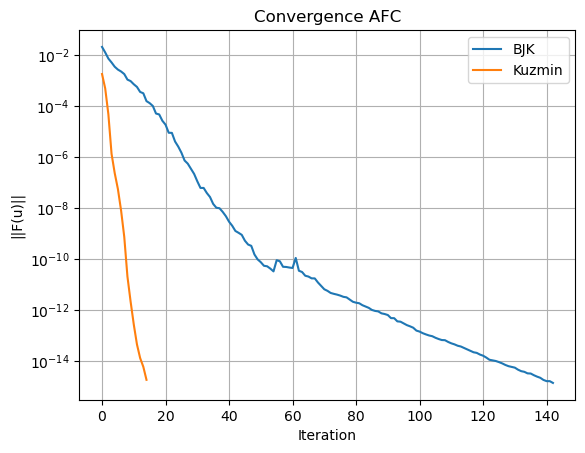

In [255]:
nx = 32
ny = 32


comm = MPI.COMM_WORLD

mesh = msh.create_unit_square(nx=nx, ny=ny, comm=comm, cell_type=msh.CellType.triangle, diagonal=msh.DiagonalType.left)

Wh = fem.functionspace(mesh=mesh, element=('P', 1))
u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)

mesh.topology.create_connectivity(1, 2)
boundary_facets = msh.exterior_facet_indices(mesh.topology)
boundary_dofs = fem.locate_dofs_topological(Wh, 1, boundary_facets)

x = ufl.SpatialCoordinate(mesh)
b = ufl.as_vector((fem.Constant(mesh, np.cos(-np.pi/3.0)), fem.Constant(mesh, np.sin(-np.pi/3.0))))
f = fem.Constant(mesh, 0.0)
eps = fem.Constant(mesh, 1e-8)

u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)


expr = ufl.conditional(
    ufl.ge(x[1], 0.7 + ufl.sin(-ufl.pi/3)/ufl.cos(-ufl.pi/3)*x[0]),
    1,
    0
) * ufl.conditional(
    ufl.Or(ufl.eq(x[1], 0), ufl.eq(x[0],1)),
    0,
    1
)
uD = interpolate_expr(expr=expr, Wh=Wh)


a = (eps* ufl.dot(ufl.grad(u), ufl.grad(v)) + ufl.dot(b, ufl.grad(u)) * v) * ufl.dx

A = expr_to_mat(a)

L = fem.assemble_vector(fem.form(f*v*ufl.dx)).array
set_dbc_vals(dbc_dofs=boundary_dofs, A=A, L=L, uD=uD)
    
u_tabata = tabata(mesh=mesh, uD=uD.x.array, dbc_dofs=boundary_dofs, eps=eps, b=b, f=f)


ak_kuzmin = F_AFC_Kuzmin(A=A, f=L, dbc_dofs=boundary_dofs)
ak_bjk = F_AFC_BJK(A=A, f=L, dbc_dofs=boundary_dofs, gamma=1)



u_kuzmin, monitor_kuzmin = ak_kuzmin.optimize(u_tabata, ftol=1e-15, maxiter=5000)
u_bjk, monitor_bjk = ak_bjk.optimize(u_tabata, ftol=1e-15, maxiter=5000)


import matplotlib.pyplot as plt

plt.semilogy(monitor_bjk.residuals, label='BJK')
plt.semilogy(monitor_kuzmin.residuals, label='Kuzmin')
plt.xlabel("Iteration")
plt.ylabel("||F(u)||")
plt.title("Convergence AFC")
plt.grid(True)
plt.legend()
plt.show()

In [70]:
from FEniCSx_solver import SUPG_grad_adjoint_method_solver

ufun = fem.Function(Wh)

mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
boundary_facets = msh.exterior_facet_indices(mesh.topology)
boundary_dofs = fem.locate_dofs_topological(Wh, mesh.topology.dim-1, boundary_facets)

bcs = [fem.dirichletbc(uD, boundary_dofs)]
u_target = fem.Function(Wh)
u_target.x.array[:] = u_bjk
loss_form = (ufun-u_target)**2 * ufl.dx

pde_data = mesh,Wh,ufun,eps,b,None,f,None,bcs

fs = SUPG_grad_adjoint_method_solver(pde_data=pde_data, loss_form=loss_form)
print(fs.optimize(ftol=1e-12, gtol=1e-12))
y_optimized = fs.yh.x.array.copy()
u_optimized = fs.uh.x.array.copy()

fs.set_weights(yh_std(directional_diameter(mesh=mesh, b=b).x.array))
print(fs.optimize(ftol=1e-12, gtol=1e-12))
y_optimized_b = fs.yh.x.array.copy()
u_optimized_b = fs.uh.x.array.copy()


fs.set_weights(np.zeros_like(yh_std(directional_diameter(mesh=mesh, b=b).x.array)))
print(fs.optimize(ftol=1e-12, gtol=1e-12))
y_optimized_z = fs.yh.x.array.copy()
u_optimized_z = fs.uh.x.array.copy()

import scipy
ub = fs._bounds.ub
lb = fs._bounds.lb

fs.set_weights(np.zeros_like(fs.yh.x.array))
fs._bounds = scipy.optimize.Bounds(lb=lb, ub=10*yh_std(h=interpolate_expr(ufl.CellDiameter(fs.uh.function_space.mesh), fs.Yh).x.array))
fs.optimize(ftol=1e-12, gtol=1e-12)
y_optimized_l = fs.yh.x.array.copy()
u_optimized_l = fs.uh.x.array.copy()

J: 0.0006834613209053048
J: 0.0003099989554759529
J: 0.0002354138520032072
J: 0.00021724440076174818
J: 0.00019642701940666944
J: 0.0001697920211498052
J: 0.00014110592179407625
J: 0.00011872404151294674
J: 0.00010547923906623257
J: 8.25245190652071e-05
J: 6.60400534269003e-05
J: 6.010372806952314e-05
J: 5.598920120950545e-05
J: 5.292784059121558e-05
J: 4.962548886822372e-05
J: 4.554394199216715e-05
J: 4.311313476773677e-05
J: 4.0273386582026636e-05
J: 3.840289098076287e-05
J: 3.625818352293881e-05
J: 3.53677363253523e-05
J: 3.490058509464358e-05
J: 3.329942158945541e-05
J: 3.181939706039143e-05
J: 2.998151217161103e-05
J: 2.8940773184198653e-05
J: 2.8172492457258814e-05
J: 2.7549299967069972e-05
J: 2.7062761652465018e-05
J: 2.6096655248790077e-05
J: 2.508504019698724e-05
J: 2.425087738501577e-05
J: 2.365530905717209e-05
J: 2.3259756156112014e-05
J: 2.28532682721044e-05
J: 2.245242409345668e-05
J: 2.226357452790187e-05
J: 2.2103506772647072e-05
J: 2.190029504284723e-05
J: 2.16405929018

In [72]:
save_input_data(
        num=0, 
        fs=fs, 
        y_optimized=y_optimized, 
        y_optimized_b=y_optimized_b, 
        y_optimized_z=y_optimized_z, 
        y_optimized_l=y_optimized_l, 
        u_optimized=u_optimized, 
        u_optimized_b=u_optimized_b, 
        u_optimized_z=u_optimized_z, 
        u_optimized_l=u_optimized_l, 
        u_kuzmin=u_kuzmin, 
        u_bjk=u_bjk, 
        u_tabata=u_tabata)


# Analysis of saved data

In [10]:
import dolfinx
from dolfinx import fem, mesh as msh
from dolfinx.io import XDMFFile
from mpi4py import MPI
from FEniCSx_solver import plot_fn
import torch
import torch_geometric
import ufl
import numpy as np
from FEniCSx_solver import interpolate_expr, SUPG_grad_adjoint_method_solver

from torch_geometric.data import Data

G = torch.load(f='data/revised_set/input_values/raw/G_0.pt', weights_only=False)
with XDMFFile(MPI.COMM_WORLD, f"data/revised_set/mesh_files/mesh_{0}.xdmf", "r") as xdmf:
    mesh = xdmf.read_mesh(name="mesh")
Wh = fem.functionspace(mesh=mesh, element=('CG', 1))
Whd = fem.functionspace(mesh=mesh, element=('DG', 0))
ufun = fem.Function(Wh)
ufun_d = fem.Function(Whd)
u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)

mesh.topology.create_connectivity(1, 2)
boundary_facets = msh.exterior_facet_indices(mesh.topology)
boundary_dofs = fem.locate_dofs_topological(Wh, 1, boundary_facets)

x = ufl.SpatialCoordinate(mesh)
b = ufl.as_vector((fem.Constant(mesh, np.cos(-np.pi/3.0)), fem.Constant(mesh, np.sin(-np.pi/3.0))))
f = fem.Constant(mesh, 0.0)
eps = fem.Constant(mesh, 1e-8)

u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)


expr = ufl.conditional(
    ufl.ge(x[1], 0.7 + ufl.sin(-ufl.pi/3)/ufl.cos(-ufl.pi/3)*x[0]),
    1,
    0
) * ufl.conditional(
    ufl.Or(ufl.eq(x[1], 0), ufl.eq(x[0],1)),
    0,
    1
)
uD = interpolate_expr(expr=expr, Wh=Wh)
bcs = [fem.dirichletbc(uD, boundary_dofs)]
pde_data = mesh,Wh,ufun,eps,b,None,f,None,bcs

u_target = fem.Function(Wh)
u_target.x.array[:] = G.u_bjk.detach().numpy()
loss_form = (ufun-u_target)**2 * ufl.dx
fs = SUPG_grad_adjoint_method_solver(pde_data=pde_data, loss_form=loss_form)

y_opt = torch.clone(G.y_optimized).detach().numpy().flatten()
y_opt_b = torch.clone(G.y_optimized_b).detach().numpy().flatten()
y_opt_z = torch.clone(G.y_optimized_z).detach().numpy().flatten()
y_opt_l = torch.clone(G.y_optimized_l).detach().numpy().flatten()
y_test = y_opt_z.copy()
bins = np.linspace(start=np.min(y_opt), stop=np.max(y_opt), num=1000)
inds =np.digitize(x=y_opt, bins=bins)-1
y_dist = bins[inds]
values, counts = np.unique(y_dist, return_counts=True)
mode = values[np.argmax(counts)]


y_test[np.isclose(y_opt, mode, atol = 1e-3)] *= 1.2
#y_test = np.where(y_opt_z>= np.percentile(y_opt_z, q =75), y_opt_z/1.2, y_opt_z)

fs.set_weights(y_test)
ufun_d.x.array[:] = y_test
u_plot = fem.Function(Wh)

print(fs.loss())
plot_fn(ufun_d, warp=False)
#plot_fn(fs.uh)


5.1790509788344206e-05


Widget(value='<iframe src="http://localhost:50167/index.html?ui=P_0x3526b6e90_9&reconnect=auto" class="pyvista…

In [239]:
fs.set_weights(y_opt)
print(fs.loss())

fs.set_weights(y_opt_z)
print(fs.loss())

fs.set_weights(y_opt_b)
print(fs.loss())

fs.set_weights(y_opt_z)
print(fs.loss())

y_test = np.where(y_opt_z>= np.percentile(y_opt_z, q =75), 0.5*y_opt_z, y_opt_z)
fs.set_weights(y_test)
print(fs.loss())

y_test2 = y_opt_z.copy()
y_test2[np.isclose(y_opt, mode, atol = 1e-3)] += 0.05
fs.set_weights(y_test2)
print(fs.loss())

def loss(y):
    main = np.where(np.abs(np.subtract(y,y_opt_z))<=1, 1/2*np.square(np.subtract(y, y_opt_z)), (np.abs(np.subtract(y,y_opt_z))-1/2))
    aux = np.square(np.subtract(y, y_opt_z))
    return 0.7*main.sum()+0.3*aux.sum()

print(loss(y_opt_l), loss(y_opt), loss(y_opt_b), loss(y_test), loss(y_test2))

2.3148281279277297e-06
1.6817222743056786e-06
2.2818870798438222e-06
1.6817222743056786e-06
0.002965252342040623
0.002118956588826377
10.99337 4.870937 5.776108 5.267987 1.8638752


In [ ]:
n = len(y_opt_z)
pert_mag = []
losses = []
max_losses = []
u_opt = torch.clone(G.u_optimized_z).cpu().detach().numpy().flatten()


for j in np.logspace(start=-8, stop=2, num=10000):
    pert = np.random.randn(n)
    pert /= np.linalg.norm(pert)
    pert *= j
    y_test = np.maximum(y_opt_z + pert, 0)
    fs.set_weights(y_test)
    print(fs.loss())
    max_losses.append(np.max(np.abs(u_opt - fs.uh.x.array)))
    losses.append(fs.loss())
    pert_mag.append(np.linalg.norm(y_test-y_opt_z))
pert_mag = np.array(pert_mag)
losses = np.array(losses)
lmax_osses = np.array(max_losses)

np.save('data/loss_arrays/pert_mag.npy', pert_mag)
np.save('data/loss_arrays/pert_losses.npy', losses)
np.save('data/loss_arrays/pert_max_losses.npy', max_losses)

1.6817222757413033e-06
1.6817222753409299e-06
1.6817222763542377e-06
1.6817222775904185e-06
1.6817222754906633e-06
1.6817222761497023e-06
1.6817222759627556e-06
1.6817222780449155e-06
1.6817222770271874e-06
1.6817222749055727e-06
1.681722279260913e-06
1.6817222770777692e-06
1.6817222778747614e-06
1.681722275922635e-06
1.6817222765972404e-06
1.6817222740020732e-06
1.6817222748004388e-06
1.6817222770166067e-06
1.6817222765168083e-06
1.6817222777881586e-06
1.6817222748108532e-06
1.6817222768356442e-06
1.6817222768144457e-06
1.68172227497706e-06
1.6817222751006198e-06
1.6817222771761157e-06
1.6817222781280287e-06
1.6817222775814781e-06
1.6817222784361051e-06
1.6817222758656011e-06
1.6817222787837207e-06
1.68172227798098e-06
1.6817222765810107e-06
1.6817222781932688e-06
1.68172227496651e-06
1.6817222766834366e-06
1.6817222803877211e-06
1.68172227798693e-06
1.6817222775371677e-06
1.6817222759995139e-06
1.6817222801632964e-06
1.6817222782907543e-06
1.681722276260642e-06
1.6817222768500497e-06

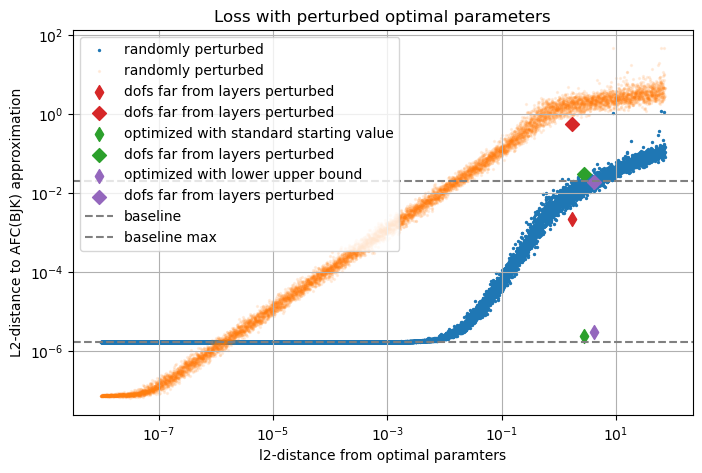

In [283]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(pert_mag, losses, s=2, alpha=1, label='randomly perturbed', color='C0')
plt.scatter(pert_mag, max_losses, s=2, alpha=0.1, label='randomly perturbed', color='C1')
fs.set_weights(y_test2)
plt.scatter(x=np.linalg.norm(y_test2-y_opt_z), y=fs.loss(), s=50, color=f"C3", label="dofs far from layers perturbed", marker='d')
plt.scatter(x=np.linalg.norm(y_test2-y_opt_z), y=np.max(np.abs(fs.uh.x.array-u_opt)), s=50, color=f"C3", label="dofs far from layers perturbed", marker='D')#, edgecolor="black", linewidth=1, zorder=2)
fs.set_weights(y_opt)
plt.scatter(x=np.linalg.norm(y_opt-y_opt_z), y=fs.loss(), s=50, color=f"C2", label="optimized with standard starting value", marker='d')
plt.scatter(x=np.linalg.norm(y_opt-y_opt_z), y=np.max(np.abs(fs.uh.x.array-u_opt)), s=50, color=f"C2", label="dofs far from layers perturbed", marker='D')#, edgecolor="black", linewidth=2, zorder=2)
fs.set_weights(y_opt_l)
plt.scatter(x=np.linalg.norm(y_opt_l-y_opt_z), y=fs.loss(), s=50, color=f"C4", label="optimized with lower upper bound", marker='d')
plt.scatter(x=np.linalg.norm(y_opt_l-y_opt_z), y=np.max(np.abs(fs.uh.x.array-u_opt)), s=50, color=f"C4", label="dofs far from layers perturbed", marker='D')#, edgecolor="black", linewidth=2, zorder=2)


fs.set_weights(y_opt_z)
plt.axhline(fs.loss(), linestyle='--', color='gray', label='baseline')
plt.axhline(np.max(np.abs(u_opt-u_bjk)), linestyle='--', color='gray', label='baseline max')
plt.legend()
plt.gca()
plt.grid()
plt.title('Loss with perturbed optimal parameters')
plt.xlabel('l2-distance from optimal paramters')
plt.ylabel('L2-distance to AFC(BJK) approximation')
plt.yscale('log')
plt.xscale('log')
plt.show()

In [282]:
print(np.max(np.abs(u_opt-u_bjk)))

0.02014626


In [18]:
pert_mag = np.array(pert_mag)